# 📊 Data Visualization — Practice Worksheet
### Tasks covering Matplotlib, Seaborn, Bokeh & Plotly

---

> 📌 **Instructions**
> - Complete **all 9 tasks** in order.
> - Each task builds on concepts covered in the lecture.
> - Fill in the `# YOUR CODE HERE` sections only — do not change the task descriptions.
> - Run each cell after completing it to verify your output.

**Libraries you will need:** `matplotlib`, `seaborn`, `bokeh`, `plotly`


## ⚙️ Setup — Run This First

Import all required libraries before starting the tasks.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from bokeh.plotting import figure, show
from bokeh.io import output_notebook
from bokeh.models import HoverTool, ColumnDataSource
%matplotlib inline
output_notebook()


---
## 📝 Task 1 — Multi-Line Plot with Matplotlib

### Background
Line plots are used to show **trends over time**. When comparing multiple series on the same chart you add a legend so readers can distinguish them.

### 🎯 Your Task
The table below shows the **monthly revenue** (in $000s) of two products over 6 months.

| Month | Product A | Product B |
|-------|-----------|-----------|
| Jan | 15 | 10 |
| Feb | 18 | 13 |
| Mar | 14 | 16 |
| Apr | 22 | 18 |
| May | 25 | 20 |
| Jun | 28 | 24 |

Create a **single line chart** that shows **both products** with:
- Different colors and markers for each line
- A legend identifying each product
- Proper axis labels and a descriptive title
- Grid lines enabled

> 💡 **Hint:** Plot both series with `plt.plot()` twice, passing `label=` each time, then call `plt.legend()`.


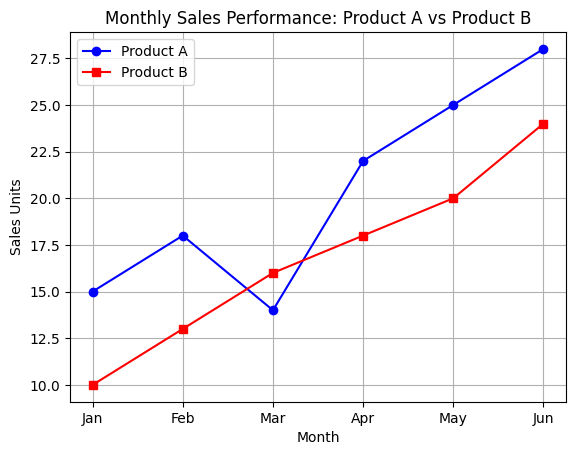

In [ ]:
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']
product_a = [15, 18, 14, 22, 25, 28]
product_b = [10, 13, 16, 18, 20, 24]

# Plot Product A line (blue color with circle markers)
plt.plot(months, product_a, label='Product A', color='blue', marker='o')

# Plot Product B line (red color with square markers)
plt.plot(months, product_b, label='Product B', color='red', marker='s')

# Add title, axis labels, legend, and grid
plt.title('Monthly Sales Performance: Product A vs Product B')
plt.xlabel('Month')
plt.ylabel('Sales Units')
plt.legend()
plt.grid(True)

# Save and display the plot
plt.savefig('product_sales_plot.png')




---
## 📝 Task 2 — Grouped Bar Chart with Matplotlib

### Background
A **grouped bar chart** places multiple bars side by side for the same category, making it easy to compare values within each group.

### 🎯 Your Task
The data below shows **exam scores** for three subjects across two classes.

| Subject | Class A | Class B |
|---------|---------|---------|
| Math | 72 | 68 |
| Science | 85 | 80 |
| English | 78 | 74 |
| History | 65 | 70 |

Create a **grouped bar chart** with:
- Two bars (Class A and Class B) side by side for each subject
- Different colors for each class
- Value labels on top of each bar
- A legend, axis labels, and a title

> 💡 **Hint:** Use `np.arange(len(subjects))` for x-positions, then offset each group with `x - 0.2` and `x + 0.2` and `width=0.4`.  
> To add labels: loop over bars using `bar.get_height()` and `plt.text()`.


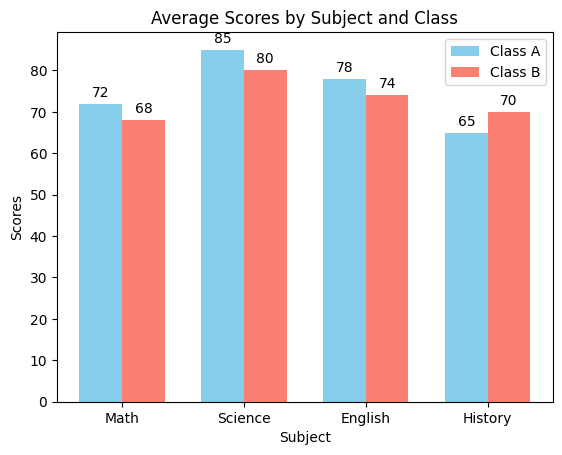

In [ ]:
import numpy as np

subjects = ['Math', 'Science', 'English', 'History']
class_a  = [72, 85, 78, 65]
class_b  = [68, 80, 74, 70]

# Create x positions using np.arange
x = np.arange(len(subjects))
width = 0.35  # width of the bars

fig, ax = plt.subplots()

# Plot Class A bars (offset left)
rects1 = ax.bar(x - width/2, class_a, width, label='Class A', color='skyblue')

# Plot Class B bars (offset right)
rects2 = ax.bar(x + width/2, class_b, width, label='Class B', color='salmon')

# Add value labels above each bar
ax.bar_label(rects1, padding=3)
ax.bar_label(rects2, padding=3)

# Add title, axis labels, legend, and x-tick labels
ax.set_title('Average Scores by Subject and Class')
ax.set_xlabel('Subject')
ax.set_ylabel('Scores')
ax.set_xticks(x)
ax.set_xticklabels(subjects)
ax.legend()

---
## 📝 Task 3 — Histogram Analysis with Matplotlib

### Background
Histograms reveal the **shape of a distribution** — whether it is symmetric, skewed, or has multiple peaks. The number of bins controls the granularity.

### 🎯 Your Task
A teacher recorded the following **test scores** for 20 students:

```
scores = [45, 55, 60, 62, 65, 65, 68, 70, 70, 72,
          75, 75, 78, 80, 82, 85, 88, 90, 92, 95]
```

**Part A:** Plot a histogram with **5 bins**.  
**Part B:** Below Part A (use `plt.subplot`), plot the **same data with 10 bins**.  
Both plots should have:
- A different color each
- Edge color set to black
- Axis labels and a title describing the bin count

> 💡 **Hint:** Use `plt.subplot(1, 2, 1)` for the first and `plt.subplot(1, 2, 2)` for the second. Call `plt.tight_layout()` at the end.


Text(0, 0.5, 'Frequency')

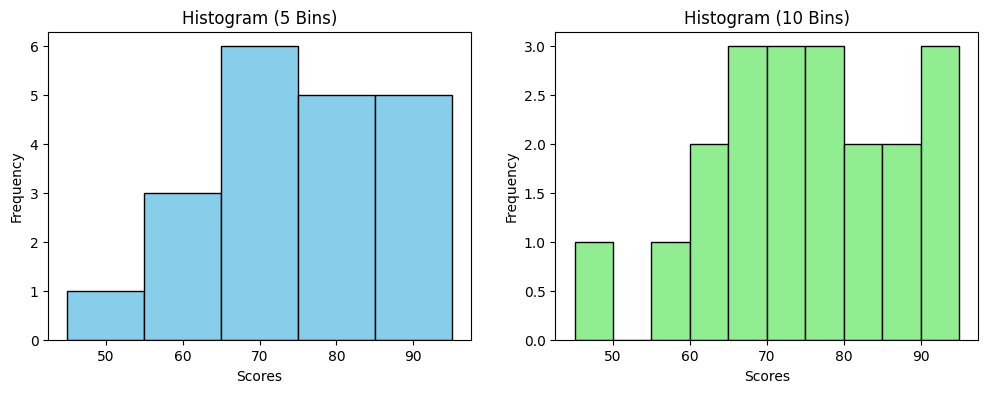

In [ ]:
scores = [45, 55, 60, 62, 65, 65, 68, 70, 70, 72,
          75, 75, 78, 80, 82, 85, 88, 90, 92, 95]

plt.figure(figsize=(12, 4))

# Part A: Histogram with 5 bins (subplot 1)
plt.subplot(1, 2, 1)
plt.hist(scores, bins=5, color='skyblue', edgecolor='black')
plt.title('Histogram (5 Bins)')
plt.xlabel('Scores')
plt.ylabel('Frequency')

# Part B: Histogram with 10 bins (subplot 2)
plt.subplot(1, 2, 2)
plt.hist(scores, bins=10, color='lightgreen', edgecolor='black')
plt.title('Histogram (10 Bins)')
plt.xlabel('Scores')
plt.ylabel('Frequency')


---
## 📝 Task 4 — Dashboard of 4 Plots with Matplotlib Subplots

### Background
Real-world reports often present **multiple charts together** in a grid layout. `plt.subplots(rows, cols)` creates this grid and returns an `axes` array.

### 🎯 Your Task
Using the data provided, create a **2×2 subplot dashboard** containing:

| Position | Chart | Data |
|----------|-------|------|
| Top-left (0,0) | Line plot | `months` vs `sales` |
| Top-right (0,1) | Bar chart | `cities` vs `population` |
| Bottom-left (1,0) | Scatter plot | `hours` vs `grades` |
| Bottom-right (1,1) | Pie chart | `categories` / `expenses` |

Each subplot must have its own title. The figure should have an overall `suptitle` of `"Monthly Dashboard"`.

> 💡 **Hint:** Access each subplot as `axes[row, col]`. For the pie chart use `axes[1,1].pie(...)`.  
> Use `fig.suptitle("Monthly Dashboard", fontsize=14)` for the main title.


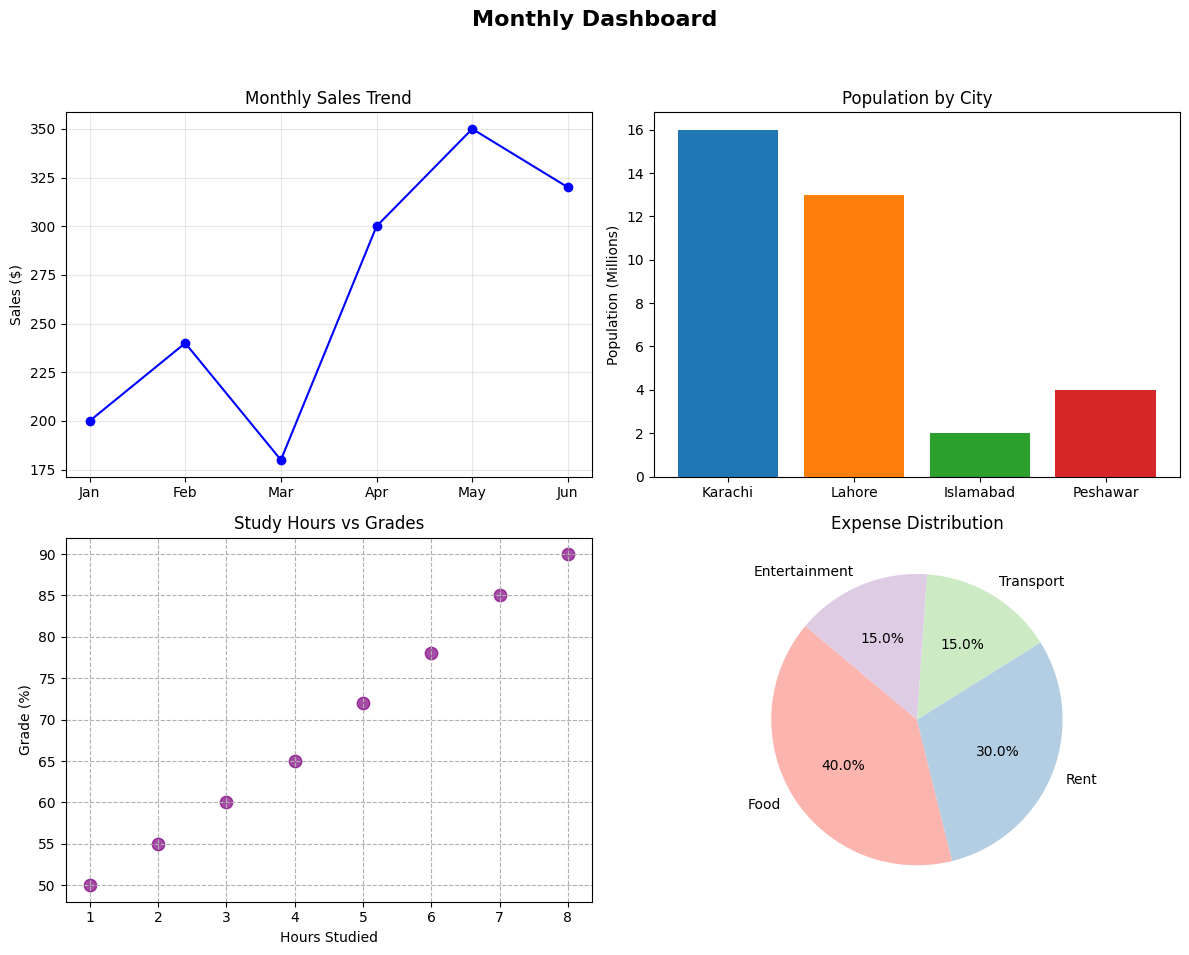

In [ ]:
months     = ['Jan','Feb','Mar','Apr','May','Jun']
sales      = [200, 240, 180, 300, 350, 320]

cities     = ['Karachi','Lahore','Islamabad','Peshawar']
population = [16, 13, 2, 4]   # millions

hours      = [1, 2, 3, 4, 5, 6, 7, 8]
grades     = [50, 55, 60, 65, 72, 78, 85, 90]

categories = ['Food', 'Rent', 'Transport', 'Entertainment']
expenses   = [40, 30, 15, 15]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Top-left: line plot of sales over months
axes[0, 0].plot(months, sales, color='blue', marker='o', linestyle='-')
axes[0, 0].set_title('Monthly Sales Trend')
axes[0, 0].set_ylabel('Sales ($)')
axes[0, 0].grid(True, alpha=0.3)

# Top-right: bar chart of city populations
axes[0, 1].bar(cities, population, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
axes[0, 1].set_title('Population by City')
axes[0, 1].set_ylabel('Population (Millions)')

# Bottom-left: scatter plot of hours vs grades
axes[1, 0].scatter(hours, grades, color='purple', s=80, alpha=0.7)
axes[1, 0].set_title('Study Hours vs Grades')
axes[1, 0].set_xlabel('Hours Studied')
axes[1, 0].set_ylabel('Grade (%)')
axes[1, 0].grid(True, linestyle='--')

# Bottom-right: pie chart of expenses
axes[1, 1].pie(expenses, labels=categories, autopct='%1.1f%%', startangle=140, colors=plt.cm.Pastel1.colors)
axes[1, 1].set_title('Expense Distribution')

fig.suptitle("Monthly Dashboard", fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


---
## 📝 Task 5 — Seaborn EDA on the `tips` Dataset

### Background
Seaborn's statistical plots make it very easy to explore relationships in a dataset. The `tips` dataset records restaurant bill information.

### 🎯 Your Task
Load the `tips` dataset and create the following **3 plots** (each in its own cell or in subplots):

**Plot 1 — Box Plot:** Distribution of `tip` amounts grouped by `day`, with `sex` as the hue.

**Plot 2 — Violin Plot:** Distribution of `total_bill` grouped by `time` (Lunch / Dinner).

**Plot 3 — Heatmap:** Correlation matrix of all numeric columns in `tips`, with annotations and the `coolwarm` colormap.

Each plot needs a descriptive title.

> 💡 **Hint for heatmap:** Use `tips.corr(numeric_only=True)` to get the correlation matrix, then pass it to `sns.heatmap(..., annot=True, cmap='coolwarm')`.


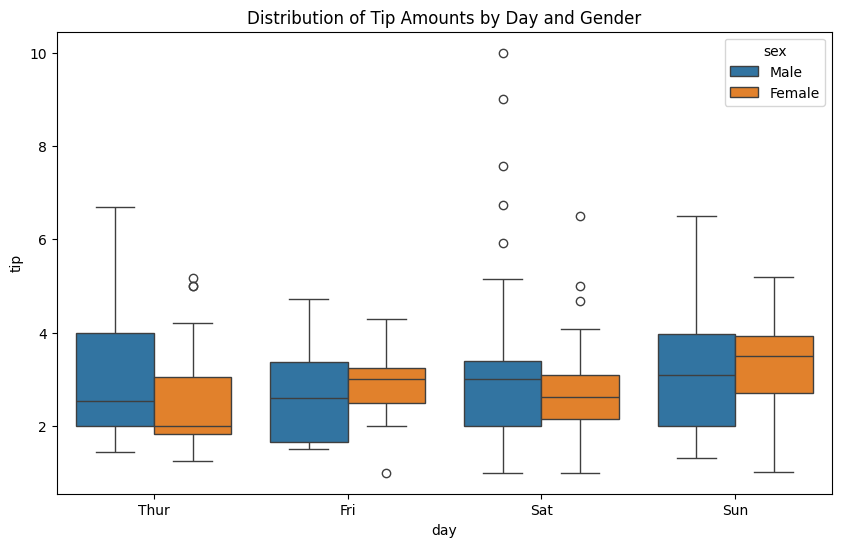

In [ ]:
tips = sns.load_dataset('tips')

# YOUR CODE HERE — Plot 1: Box plot (tip by day, hue=sex)
plt.figure(figsize=(10, 6))
sns.boxplot(data=tips, x='day', y='tip', hue='sex')
plt.title('Distribution of Tip Amounts by Day and Gender')
plt.show()

/tmp/ipykernel_433/2162062056.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=tips, x='time', y='total_bill', palette="muted")


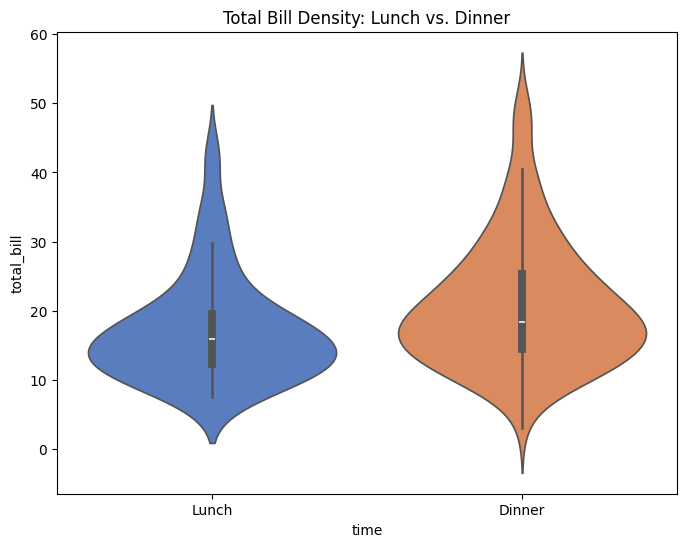

In [ ]:
# YOUR CODE HERE — Plot 2: Violin plot (total_bill by time)
plt.figure(figsize=(8, 6))
sns.violinplot(data=tips, x='time', y='total_bill', palette="muted")
plt.title('Total Bill Density: Lunch vs. Dinner')
plt.show()

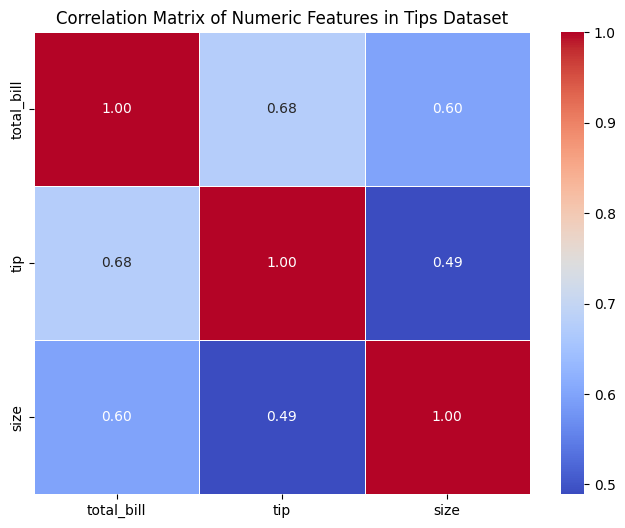

In [ ]:
# YOUR CODE HERE — Plot 3: Correlation heatmap
plt.figure(figsize=(8, 6))
# Calculate the correlation matrix for numeric columns only
corr_matrix = tips.corr(numeric_only=True)

# Plot the heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Numeric Features in Tips Dataset')
plt.show()

---
## 📝 Task 6 — Seaborn Scatter Plot with Regression Line

### Background
`sns.scatterplot` shows raw data points; adding `sns.regplot` or `sns.lmplot` overlays a **linear regression line** with a confidence band, making trends easier to read.

### 🎯 Your Task
Using the `tips` dataset:

1. Create a **scatter plot** of `total_bill` (x-axis) vs `tip` (y-axis), colored by `smoker` status.
2. On a **separate plot**, use `sns.regplot` (or `sns.lmplot`) to show the same relationship with a **regression line** (ignore the smoker grouping here).

Both plots need titles, axis labels, and a legend where applicable.

> 💡 **Hint:** For the regression plot try `sns.regplot(x='total_bill', y='tip', data=tips, scatter_kws={'alpha':0.5})`.


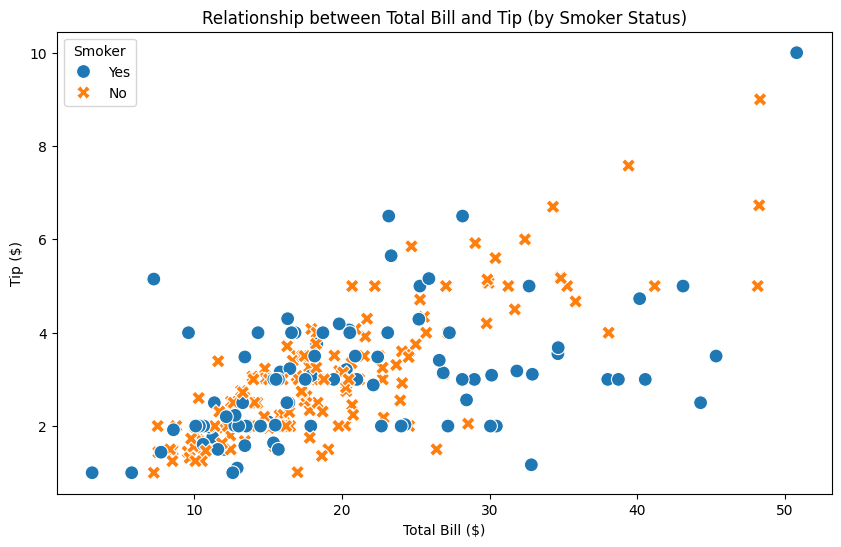

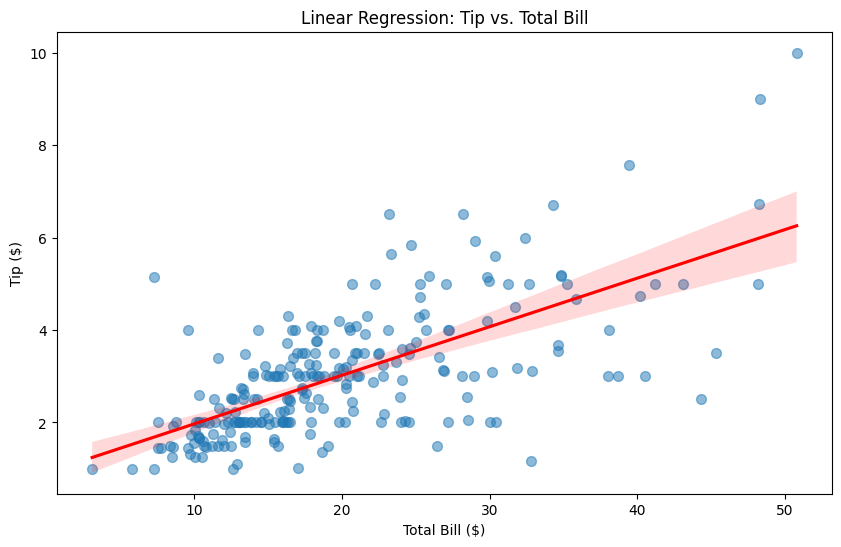

In [ ]:
tips = sns.load_dataset('tips')

# YOUR CODE HERE — Part 1: Scatter plot colored by smoker status
plt.figure(figsize=(10, 6))
sns.scatterplot(data=tips, x='total_bill', y='tip', hue='smoker', style='smoker', s=100)

plt.title('Relationship between Total Bill and Tip (by Smoker Status)')
plt.xlabel('Total Bill ($)')
plt.ylabel('Tip ($)')
plt.legend(title='Smoker')
plt.show()

# YOUR CODE HERE — Part 2: Regression plot (total_bill vs tip)
plt.figure(figsize=(10, 6))
# Using regplot as requested in the hint
sns.regplot(data=tips, x='total_bill', y='tip',
            scatter_kws={'alpha':0.5, 's':50},
            line_kws={'color':'red'})

plt.title('Linear Regression: Tip vs. Total Bill')
plt.xlabel('Total Bill ($)')
plt.ylabel('Tip ($)')
plt.show()


---
## 📝 Task 7 — Interactive Line Plot with Bokeh

### Background
Bokeh creates **interactive, browser-rendered** plots. The `HoverTool` lets users see exact data values when they hover over points.

### 🎯 Your Task
Create an **interactive Bokeh line plot** showing website traffic over 7 days:

```
days    = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
visitors = [120, 180, 150, 200, 250, 300, 270]
```

Requirements:
- Line width = 2, color of your choice
- Circle markers on each data point (size = 8)
- A `HoverTool` that shows the day and visitor count on hover
- Proper title and axis labels

> 💡 **Hint:** To use HoverTool with plain lists, convert data to a `ColumnDataSource`.  
> `source = ColumnDataSource(data=dict(days=days, visitors=visitors))`  
> Then use `p.line(x='days', y='visitors', source=source)` and  
> `HoverTool(tooltips=[("Day", "@days"), ("Visitors", "@visitors")])`.


In [ ]:
from bokeh.plotting import figure, show, output_file
from bokeh.models import ColumnDataSource, HoverTool

# 1. Prepare the data
days     = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
visitors = [120, 180, 150, 200, 250, 300, 270]

# 2. Convert to ColumnDataSource (Best practice for Bokeh)
source = ColumnDataSource(data=dict(days=days, visitors=visitors))

# 3. Create a new plot with a title and axis labels
p = figure(x_range=days, height=400, title="Weekly Website Traffic",
           toolbar_location="above", tools="pan,wheel_zoom,box_zoom,reset")

p.xaxis.axis_label = 'Day of the Week'
p.yaxis.axis_label = 'Number of Visitors'

# 4. Add the line renderer
p.line(x='days', y='visitors', source=source,
       line_width=2, color="navy", legend_label="Daily Visitors")

# 5. Add scatter markers on each data point
p.scatter(x='days', y='visitors', source=source,
          marker="circle", size=8,
          color="orange", fill_alpha=0.6)

# 6. Configure the HoverTool
hover = HoverTool()
hover.tooltips = [
    ("Day", "@days"),
    ("Visitors", "@visitors")
]
p.add_tools(hover)

# 7. Style the legend and layout
p.legend.location = "top_left"
p.legend.click_policy = "hide" # Allows clicking legend to hide the line

# Display the plot
show(p)

---
## 📝 Task 8 — Interactive Charts with Plotly Express

### Background
Plotly Express (imported as `px`) creates fully interactive charts in one or two lines. Charts support hover info, zoom, and filtering by legend clicks out of the box.

### 🎯 Your Task
Use the **built-in `gapminder` dataset** (`px.data.gapminder()`) to create:

**Part A — Animated Scatter Plot:**  
Plot `gdpPercap` (x, log scale) vs `lifeExp` (y), with:
- Bubble size = `pop`
- Color = `continent`
- Animation frame = `year`
- Title: "GDP vs Life Expectancy Over Time"

**Part B — Bar Chart (2007 snapshot):**  
Filter for `year == 2007` and `continent == 'Asia'`. Plot a bar chart of `country` vs `lifeExp`, sorted descending. Title: "Life Expectancy in Asia (2007)".

> 💡 **Hint for Part A:** `px.scatter(..., animation_frame='year', log_x=True, size='pop', size_max=60)`  
> 💡 **Hint for Part B:** Use `df.sort_values('lifeExp', ascending=False)` before plotting.


In [ ]:
import plotly.express as px

# Load the built-in gapminder dataset
df = px.data.gapminder()

# --- Part A: Animated Scatter Plot ---
fig_a = px.scatter(
    df,
    x="gdpPercap",
    y="lifeExp",
    animation_frame="year",
    animation_group="country",
    size="pop",
    color="continent",
    hover_name="country",
    log_x=True,
    size_max=60,
    range_x=[100, 100000],
    range_y=[25, 90],
    title="GDP vs Life Expectancy Over Time"
)

In [ ]:
# YOUR CODE HERE — Part B: Bar chart for Asia in 2007
# 1. Filter the data
df_2007_asia = df[(df['year'] == 2007) & (df['continent'] == 'Asia')]

# 2. Sort descending
df_2007_asia = df_2007_asia.sort_values('lifeExp', ascending=False)

# 3. Create the bar chart
fig_b = px.bar(
    df_2007_asia,
    x='country',
    y='lifeExp',
    color='lifeExp',
    title="Life Expectancy in Asia (2007)",
    labels={'lifeExp': 'Life Expectancy (Years)', 'country': 'Country'}
)

# Display the plots
fig_a.show()
fig_b.show()

---
## 📝 Task 9 — Choose Your Own Visualization

### Background
Good data visualization starts with choosing the **right chart type** for your data and message. This task tests that judgment.

### 🎯 Your Task
Below is a dataset of a fictional **e-commerce store's weekly performance**:

```python
data = {
    'Day':        ['Mon','Tue','Wed','Thu','Fri','Sat','Sun'],
    'Orders':     [45,   62,   58,   70,   95,   110,  80 ],
    'Revenue':    [900,  1240, 1160, 1400, 1900, 2200, 1600],
    'Returns':    [2,    3,    5,    4,    6,    8,    5   ],
    'Category':   ['Electronics','Clothing','Books','Electronics','Clothing','Books','Electronics']
}
```

**You must create exactly 3 different chart types** using any combination of Matplotlib, Seaborn, or Plotly. For each chart:
1. Clearly state (in a comment) **which chart type you chose and why** it suits that particular relationship
2. Include a title, axis labels, and any useful annotations

**Suggested angles to explore** (pick any 3):
- Trend of `Orders` or `Revenue` over the week
- Proportion of `Orders` by `Category`
- Relationship between `Orders` and `Revenue`
- Comparison of `Returns` vs `Orders` by day

> 💡 There is no single correct answer here. Focus on making each chart **clear and informative**.


/tmp/ipykernel_433/871987732.py:37: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




Text(0, 0.5, 'Number of Returns')

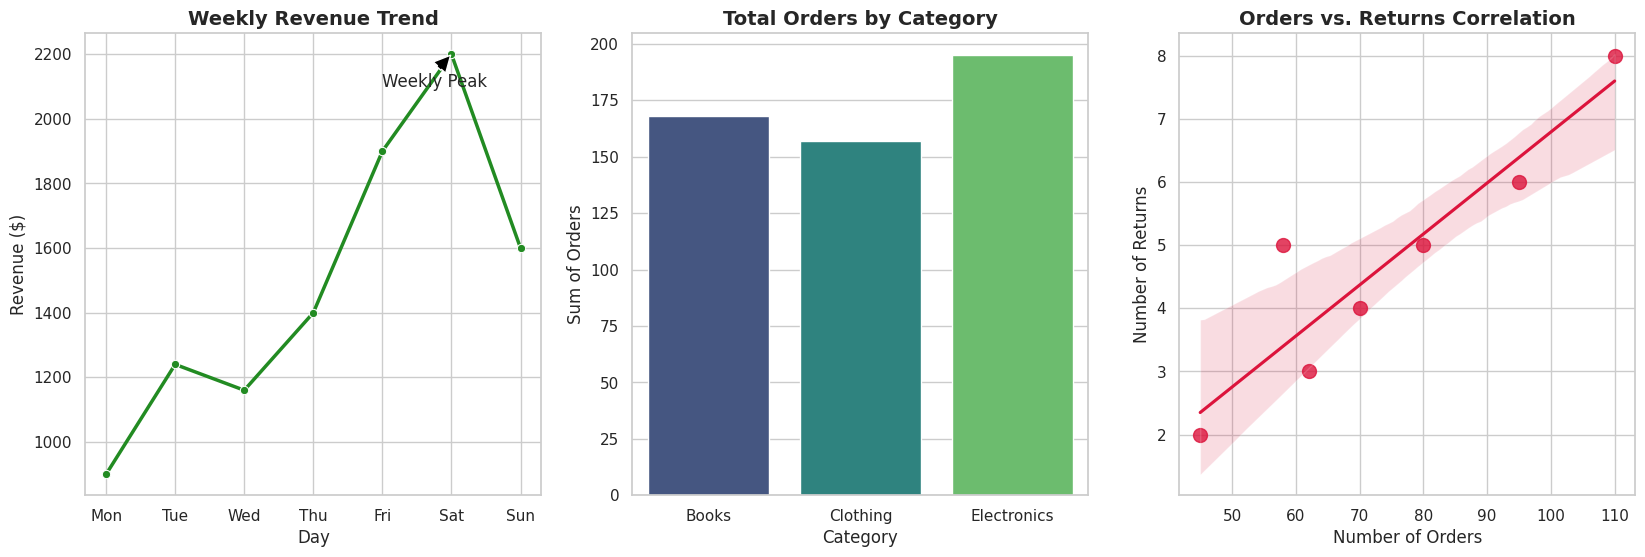

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

df = pd.DataFrame({
    'Day':      ['Mon','Tue','Wed','Thu','Fri','Sat','Sun'],
    'Orders':   [45,   62,   58,   70,   95,  110,   80 ],
    'Revenue':  [900, 1240, 1160, 1400, 1900, 2200, 1600],
    'Returns':  [2,    3,    5,    4,    6,    8,    5   ],
    'Category': ['Electronics','Clothing','Books','Electronics','Clothing','Books','Electronics']
})

# ── Chart 1 ──────────────────────────────────────────────────────────────
# Chart type chosen:
# Why it suits this data:

# Set the visual style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- Chart 1: Line Plot (Trend Analysis) ---
# WHY: A line plot is the gold standard for visualizing time-series data or
# trends over a sequential period (like a week).
sns.lineplot(ax=axes[0], data=df, x='Day', y='Revenue', marker='o', color='forestgreen', linewidth=2.5)
axes[0].set_title('Weekly Revenue Trend', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Revenue ($)')
# Annotation for the peak
axes[0].annotate('Weekly Peak', xy=('Sat', 2200), xytext=('Fri', 2100),
                 arrowprops=dict(facecolor='black', shrink=0.05))

# --- Chart 2: Bar Chart (Category Performance) ---
# WHY: Bar charts are ideal for comparing categorical data.
# Here we sum the orders to see which product type is driving volume.
category_data = df.groupby('Category')['Orders'].sum().reset_index()
sns.barplot(ax=axes[1], data=category_data, x='Category', y='Orders', palette='viridis')
axes[1].set_title('Total Orders by Category', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Sum of Orders')

# --- Chart 3: Scatter Plot (Correlation/Efficiency) ---
# WHY: Scatter plots reveal the relationship between two continuous variables.
# We want to see if higher order volume correlates with higher return rates.
sns.regplot(ax=axes[2], data=df, x='Orders', y='Returns', scatter_kws={'s':100}, color='crimson')
axes[2].set_title('Orders vs. Returns Correlation', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Number of Orders')
axes[2].set_ylabel('Number of Returns')



In [ ]:
# ── Chart 2 ──────────────────────────────────────────────────────────────
# Chart type chosen:
# Why it suits this data:


In [ ]:
# ── Chart 3 ──────────────────────────────────────────────────────────────
# Chart type chosen:
# Why it suits this data:

# YOUR CODE HERE


---
## 🤔 Reflection Questions

Answer the following in the code cell below as comments:

1. What is the main advantage of using **Seaborn** over raw Matplotlib for statistical plots?
2. When would you choose **Bokeh** over **Plotly**, and vice versa?
3. In Task 3, how does changing the number of bins affect your interpretation of the distribution?
4. Why is a **pie chart** generally not recommended when you have more than 5–6 categories?
5. What does a **violin plot** show that a **box plot** does not?


In [ ]:
# 1. Main advantage of Seaborn over raw Matplotlib:
# Seaborn is specifically designed for statistical exploration. It automates
# complex tasks like grouping (hue), calculating confidence intervals for
# regression, and mapping colors to categories. It also has much better
# default aesthetics, making "publication-ready" plots with far less code.

# 2. Choosing between Bokeh and Plotly:
# - Choose BOKEH when: You need high-performance, low-level control over
#   custom interactions, or you are building a complex standalone web
#   dashboard where you want to define exactly how tools (like Hover) behave.
# - Choose PLOTLY when: You need rapid prototyping. Plotly Express is
#   unbeatable for creating high-level interactive charts (like animated
#   maps or 3D plots) in just one or two lines of code.

# 3. Effect of changing bins in Task 3:
# - Fewer bins (e.g., 5): "Smoothes" the data, showing the overall trend
#   (e.g., is it bell-shaped?). However, it can hide small gaps or outliers.
# - More bins (e.g., 10+): Increases granularity, showing exactly where
#   scores cluster. Too many bins, however, can make the data look
#   "noisy" and jagged, making it harder to see the general distribution.

# 4. Why avoid Pie Charts with > 5-6 categories:
# Humans are much better at comparing lengths (bar charts) than comparing
# angles or areas. As you add more slices, they become too thin to
# distinguish, the labels become cluttered, and it becomes nearly
# impossible to tell which of two similar-sized slices is actually larger.

# 5. Violin Plot vs. Box Plot:
# A box plot only shows summary statistics (median, quartiles, outliers).
# A VIOLIN PLOT adds a Kernel Density Plot (the "fat" part of the shape),
# which shows the probability density of the data. This reveals "multimodal"
# distributions—for example, if a dataset has two distinct peaks, a box
# plot might look normal, but a violin plot will show two bulges.